# Effet de JDAC et de ses variantes sur l'épaisseur corticale (ds004332, pipeline rigide)

**Objectif.** Déterminer si JDAC corrige le biais de mouvement sur l'épaisseur corticale, ou s'il applique un lissage uniforme, et situer deux variantes sans débruiteur.

**Cinq conditions de traitement**, toutes en pipeline rigide :
- `brut` : image brute vers FreeSurfer ;
- `preproc` : N4 + recalage rigide MNI + SynthStrip ;
- `jdac` : JDAC complet (débruiteur + anti-artefact, boucle itérative) ;
- `jdac_antiartonly` : réseau anti-artefact appliqué une seule fois ;
- `jdac_nodenoise` : boucle de JDAC sans débruiteur, anti-artefact appliqué jusqu'à quatre fois.

**Cadre.** Une acquisition est définie par sujet, consigne (still / nodding / shaking) et condition de traitement. L'épaisseur vient de FreeSurfer ; le mouvement est quantifié par le score Agitation (continu, en mm).

**Critère.** Une correction du mouvement réduit la pente de l'épaisseur en fonction de l'Agitation (effet du mouvement atténué). Un lissage déplace l'épaisseur globale (offset) sans modifier cette pente. Un immobile n'a rien à corriger : tout écart entre conditions sur un immobile mesure le lissage ou l'offset introduit par le traitement.

**Acquisitions exclues (recon-all non abouti).**

| condition | n | runs manquants | cause |
|---|---|---|---|
| brut | 65/66 | sub-01_run-03 | surface piale (mouvement sévère) |
| preproc | 64/66 | sub-10_run-01 ; sub-11_run-03 | normalisation d'intensité ; réparation de topologie |
| jdac | 64/66 | sub-10_run-03 ; sub-11_run-03 | réparation de topologie |
| jdac_antiartonly | 66/66 | aucun | |
| jdac_nodenoise | 65/66 | sub-22_run-01 | cervelet inclus dans le volume rempli |

Notes :
- Les échecs shaking (sub-10, sub-11 run-03) viennent de défauts de topologie de surface trop nombreux à réparer, propres aux acquisitions très bougées.
- sub-10_run-01 échoue en preproc (matière blanche anormalement brillante, normalisation d'intensité) mais aboutit en jdac : le lissage de JDAC comprime le contraste et rétablit la normalisation.
- sub-22_run-01 est un scan immobile ; son absence en jdac_nodenoise réduit d'une unité l'effectif de l'étape 1 pour cette condition.

## 1. Données et chargement

Les cinq conditions sont réunies dans un tableau empilé : une ligne par acquisition × hémisphère × région × condition, complété par le score Agitation, l'âge et le sexe. Le brut est stocké en format empilé (colonne `ThickAvg`) ; les quatre autres conditions sont en format en colonnes (une ligne par acquisition, une colonne par région) et sont dépliées par `melt`. Les CSV des deux variantes sont rangés dans un dossier par variante (`thickness_jdac_<variante>_rigid/`).

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from IPython.display import display
import warnings; warnings.filterwarnings("ignore")

def show(df, caption="", fmt="{:.3f}"):
    # Tableau lisible, zébré, avec titre.
    sty = (df.style.format(fmt, na_rep="")
             .set_caption(caption)
             .set_table_styles([
                 {"selector": "caption", "props": "caption-side:top;font-weight:bold;font-size:13px;text-align:left;padding:6px 0;"},
                 {"selector": "th", "props": "background-color:#d9e1f2;padding:6px 14px;font-size:13px;text-align:center;"},
                 {"selector": "td", "props": "padding:6px 14px;font-size:13px;text-align:right;"},
                 {"selector": "tbody tr:nth-child(odd)", "props": "background-color:#f5f5f5;"},
             ]))
    display(sty)

HOME  = Path.home()
REPO  = HOME / "Documents/jdac-motion-correction"
DERIV = HOME / "Documents/derivatives/ds004332"
BRUTE_CSV    = REPO / "results/ds004332/phase1_RAW/ThickAvg_phase1_complete.csv"
AGIT_CSV     = REPO / "results/ds004332/agitation/ds004332_agitation_clinica.csv"
PARTICIPANTS = HOME / "Documents/raw_datasets/ds004332/participants.tsv"

CONDITIONS = ["brut", "preproc", "jdac", "jdac_antiartonly", "jdac_nodenoise"]
COLORS = {"brut": "tab:gray", "preproc": "tab:blue", "jdac": "tab:red",
          "jdac_antiartonly": "tab:orange", "jdac_nodenoise": "tab:green"}
CONSIGNE = {"run-01": "still", "run-02": "nodding", "run-03": "shaking"}

# Chemin du CSV en colonnes pour chaque condition (rigide). Les variantes sont dans un sous-dossier.
WIDE_PATH = {
    "preproc":          "thickness_preproc_rigid_{h}.csv",
    "jdac":             "thickness_jdac_rigid_{h}.csv",
    "jdac_antiartonly": "thickness_jdac_antiartonly_rigid/thickness_jdac_antiartonly_rigid_{h}.csv",
    "jdac_nodenoise":   "thickness_jdac_nodenoise_rigid/thickness_jdac_nodenoise_rigid_{h}.csv",
}

def load_brut():
    # Brut : format empilé (une ligne par mesure), colonne ThickAvg. sub-01_run-03 retiré (ThickAvg=0).
    d = pd.read_csv(BRUTE_CSV)
    d = d[d["ThickAvg"] > 0].copy()
    d["run"] = d["subject"].str.split("_").str[1]
    d["subject"] = d["subject"].str.split("_").str[0]
    d = d.rename(columns={"ThickAvg": "thickness"})
    d["condition"] = "brut"
    return d[["subject", "run", "hemi", "region", "thickness", "condition"]]

def load_wide(condition):
    # preproc / jdac / variantes : format en colonnes (une ligne par acquisition, une colonne par région).
    frames = []
    for hemi in ["lh", "rh"]:
        w = pd.read_csv(DERIV / WIDE_PATH[condition].format(h=hemi), sep="\t")
        w = w.rename(columns={w.columns[0]: "id"})
        cols = [c for c in w.columns if c.endswith("_thickness") and "MeanThickness" not in c]
        long = w.melt(id_vars="id", value_vars=cols, var_name="rr", value_name="thickness")
        long["hemi"] = hemi
        long["region"] = (long["rr"].str.replace(f"{hemi}_", "", regex=False)
                                     .str.replace("_thickness", "", regex=False))
        frames.append(long)
    d = pd.concat(frames, ignore_index=True)
    d["subject"] = d["id"].str.split("_").str[0]
    d["run"] = d["id"].str.split("_").str[1]
    d["condition"] = condition
    return d[["subject", "run", "hemi", "region", "thickness", "condition"]]

thick = pd.concat([load_brut()] + [load_wide(c) for c in CONDITIONS if c != "brut"],
                  ignore_index=True)
thick = thick[thick["thickness"] > 0].copy()

agit  = pd.read_csv(AGIT_CSV).rename(columns={"condition": "run", "sub": "subject", "motion": "agitation"})
demog = pd.read_csv(PARTICIPANTS, sep="\t").rename(columns={"participant_id": "subject"})
demog["sex_bin"] = (demog["sex"] == "F").astype(int)

df = thick.merge(agit[["subject", "run", "agitation"]], on=["subject", "run"], how="inner")
df = df.merge(demog[["subject", "age", "sex_bin"]], on="subject", how="left")
df["consigne"] = df["run"].map(CONSIGNE)
df["condition"] = pd.Categorical(df["condition"], categories=CONDITIONS)

print("Tableau empilé :", df.shape[0], "lignes (acquisition x région x condition)")
print("Acquisitions par condition :")
print(df.groupby("condition", observed=True).apply(lambda x: x.groupby(["subject", "run"]).ngroups))
df.head()

Tableau empilé : 22031 lignes (acquisition x région x condition)
Acquisitions par condition :
condition
brut                65
preproc             64
jdac                64
jdac_antiartonly    66
jdac_nodenoise      65
dtype: int64


,subject,run,hemi,region,thickness,condition,agitation,age,sex_bin,consigne
0,sub-01,run-01,lh,bankssts,2.679,brut,0.199097,21,0,still
1,sub-01,run-01,lh,caudalanteriorcingulate,2.487,brut,0.199097,21,0,still
2,sub-01,run-01,lh,caudalmiddlefrontal,2.859,brut,0.199097,21,0,still
3,sub-01,run-01,lh,cuneus,1.945,brut,0.199097,21,0,still
4,sub-01,run-01,lh,entorhinal,3.361,brut,0.199097,21,0,still


## 2. Agrégation : épaisseur corticale moyenne par acquisition

Moyenne non pondérée des 68 régions, par acquisition × condition. Cette mesure globale sert aux étapes 1 à 3 ; la même méthode est appliquée aux cinq conditions, donc les valeurs sont comparables.

In [2]:
g = (df.groupby(["subject", "run", "consigne", "condition"], observed=True)
       .agg(thickness=("thickness", "mean"),
            agitation=("agitation", "first"),
            age=("age", "first"),
            sex_bin=("sex_bin", "first"))
       .reset_index())

print(g.shape[0], "lignes (une par acquisition x condition). Exemple, sub-01 :")
g[g["subject"] == "sub-01"].sort_values(["condition", "run"])

324 lignes (une par acquisition x condition). Exemple, sub-01 :


,subject,run,consigne,condition,thickness,agitation,age,sex_bin
0,sub-01,run-01,still,brut,2.739765,0.199097,21,0
5,sub-01,run-02,nodding,brut,2.542824,0.255442,21,0
1,sub-01,run-01,still,preproc,2.673632,0.199097,21,0
6,sub-01,run-02,nodding,preproc,2.567118,0.255442,21,0
10,sub-01,run-03,shaking,preproc,2.461603,3.161867,21,0
2,sub-01,run-01,still,jdac,2.596309,0.199097,21,0
7,sub-01,run-02,nodding,jdac,2.461162,0.255442,21,0
11,sub-01,run-03,shaking,jdac,2.384618,3.161867,21,0
3,sub-01,run-01,still,jdac_antiartonly,2.689691,0.199097,21,0
8,sub-01,run-02,nodding,jdac_antiartonly,2.616853,0.255442,21,0


## 3. Étape 1 (plan Sylvain) — Épaisseur sur les scans immobiles

Sur un scan immobile (consigne `still`, run-01), il n'y a pas de mouvement à corriger. Toute différence d'épaisseur entre conditions vient donc du traitement lui-même : lissage, offset ou modification d'intensité, pas d'une correction du mouvement. Cette étape isole cet effet propre à chaque condition, avant toute analyse liée à l'Agitation.

`jdac_nodenoise` a un immobile de moins (sub-22_run-01 exclu).

,epaisseur_moy,ecart_type,n
condition,,,
brut,2.595,0.061,22
preproc,2.518,0.068,21
jdac,2.435,0.101,22
jdac_antiartonly,2.418,0.117,22
jdac_nodenoise,2.378,0.099,21


,ecart_mm,ecart_%
condition,,
preproc,-0.077,-2.96
jdac,-0.160,-6.16
jdac_antiartonly,-0.177,-6.83
jdac_nodenoise,-0.216,-8.34


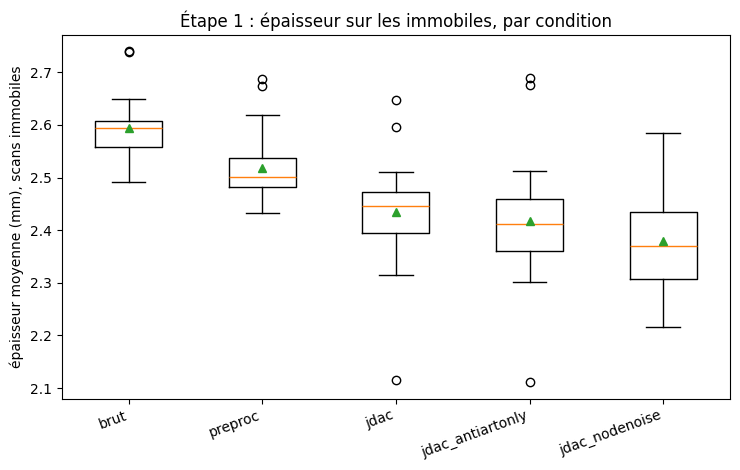

In [3]:
imm = g[g["consigne"] == "still"].copy()

tbl = imm.pivot_table(index="condition", values="thickness", aggfunc=["mean", "std", "count"], observed=True)
tbl.columns = ["epaisseur_moy", "ecart_type", "n"]
tbl = tbl.reindex(CONDITIONS)
show(tbl, "Épaisseur moyenne (mm) sur les scans immobiles, par condition",
     {"epaisseur_moy": "{:.3f}", "ecart_type": "{:.3f}", "n": "{:.0f}"})

# Écart au brut sur les immobiles (mm et %)
ref = tbl.loc["brut", "epaisseur_moy"]
ecart = pd.DataFrame({
    "ecart_mm": tbl["epaisseur_moy"] - ref,
    "ecart_%": 100 * (tbl["epaisseur_moy"] - ref) / ref,
}).drop(index="brut")
show(ecart, "Écart au brut sur les scans immobiles (offset / lissage)",
     {"ecart_mm": "{:+.3f}", "ecart_%": "{:+.2f}"})

fig, ax = plt.subplots(figsize=(7.5, 4.8))
data = [imm[imm["condition"] == c]["thickness"].dropna() for c in CONDITIONS]
bp = ax.boxplot(data, labels=CONDITIONS, showmeans=True)
ax.set_ylabel("épaisseur moyenne (mm), scans immobiles")
ax.set_title("Étape 1 : épaisseur sur les immobiles, par condition")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

*Lecture (après exécution).* Un écart négatif marqué au brut sur les immobiles signale un lissage ou un offset appliqué à des images qui n'avaient rien à corriger. Comparer JDAC complet à ses variantes sans débruiteur indique la part de cet effet attribuable au module de débruitage.

## 4. Vue descriptive par consigne (still / nodding / shaking)

Lecture descriptive, sans test : comparaison des consignes imposées au sujet dans chaque condition. La consigne n'est pas une mesure directe du mouvement (nodding et shaking se recouvrent en Agitation), elle sert d'entrée intuitive avant l'analyse continue.

In [4]:
piv = g.pivot_table(index="consigne", columns="condition", values="thickness",
                   aggfunc="mean", observed=True)
piv = piv.reindex(["still", "nodding", "shaking"])[CONDITIONS]
show(piv, "Épaisseur moyenne (mm) par consigne x condition", "{:.3f}")

# Variation relative au still de la même condition (%)
motion = 100 * (piv - piv.loc["still"]) / piv.loc["still"]
show(motion, "Effet de la consigne : variation relative au still de la même condition (%)", "{:+.2f}")

condition,brut,preproc,jdac,jdac_antiartonly,jdac_nodenoise
consigne,,,,,
still,2.595,2.518,2.435,2.418,2.378
nodding,2.503,2.500,2.425,2.524,2.564
shaking,2.332,2.347,2.341,2.441,2.580


condition,brut,preproc,jdac,jdac_antiartonly,jdac_nodenoise
consigne,,,,,
still,+0.00,+0.00,+0.00,+0.00,+0.00
nodding,-3.55,-0.71,-0.42,+4.40,+7.81
shaking,-10.12,-6.80,-3.84,+0.97,+8.46


*Lecture (après exécution).* Une chute d'épaisseur du still vers le shaking plus faible pour une condition qu'en brut suggère une atténuation de l'effet apparent du mouvement. Elle est à croiser avec l'étape 1 : si l'épaisseur des still baisse aussi, l'aplatissement vient en partie d'un effet global, pas d'une restauration des scans bougés.

## 5. Étape 2 (plan Sylvain) — Pentes épaisseur ~ Agitation par condition

Association entre le score de mouvement mesuré et l'épaisseur, par condition. Deux lectures complémentaires : une pente globale (toutes acquisitions) et des pentes intra-sujet (une régression par sujet, qui neutralise les différences d'épaisseur de base entre sujets). Une pente moins négative après traitement indique une atténuation de l'effet du mouvement.

Pente globale épaisseur ~ Agitation (mm par unité) :
  brut            : -0.0679   (p=3.4e-05)
  preproc         : -0.0349   (p=0.015)
  jdac            : -0.0140   (p=0.28)
  jdac_antiartonly: +0.0293   (p=0.069)
  jdac_nodenoise  : +0.0888   (p=2.5e-06)


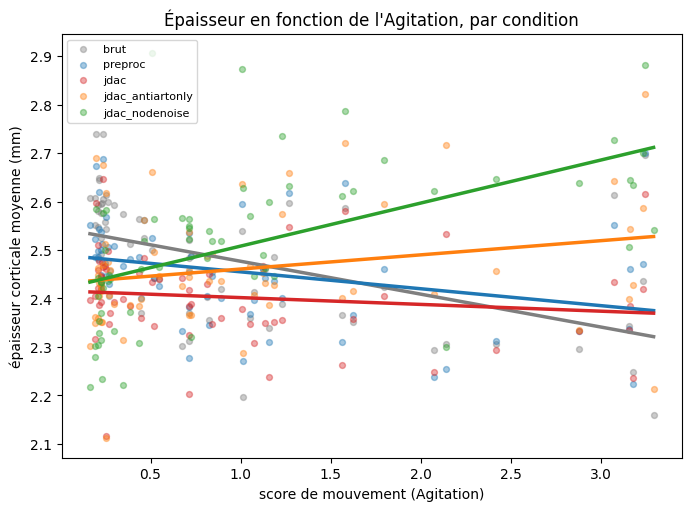

In [5]:
# Pente globale par condition
fig, ax = plt.subplots(figsize=(8, 5.5))
print("Pente globale épaisseur ~ Agitation (mm par unité) :")
xs = np.linspace(g["agitation"].min(), g["agitation"].max(), 50)
for c in CONDITIONS:
    sub = g[g["condition"] == c]
    ax.scatter(sub["agitation"], sub["thickness"], s=18, alpha=0.40, color=COLORS[c], label=c)
    sl, inter, r, p, se = stats.linregress(sub["agitation"], sub["thickness"])
    ax.plot(xs, inter + sl * xs, color=COLORS[c], lw=2.5)
    print(f"  {c:16s}: {sl:+.4f}   (p={p:.2g})")
ax.set_xlabel("score de mouvement (Agitation)")
ax.set_ylabel("épaisseur corticale moyenne (mm)")
ax.set_title("Épaisseur en fonction de l'Agitation, par condition")
ax.legend(fontsize=8); plt.show()

Pente médiane intra-sujet par condition :
condition
brut               -0.1601
preproc            -0.1034
jdac               -0.0569
jdac_antiartonly    0.0163
jdac_nodenoise      0.1382
Name: slope, dtype: float64


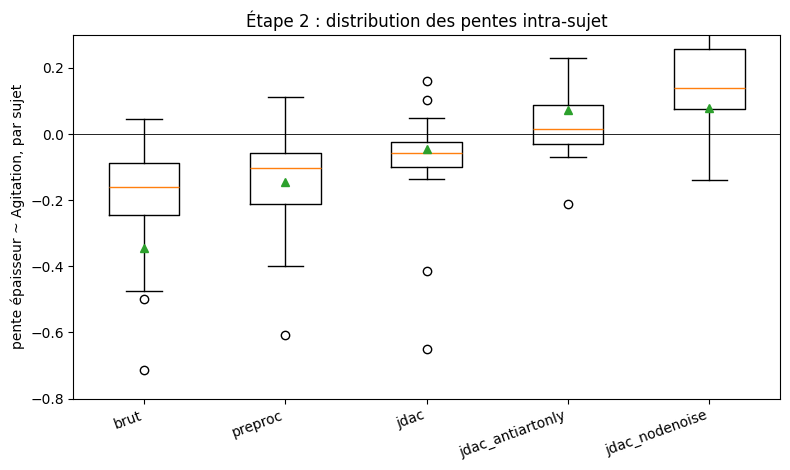


Tests appariés (Wilcoxon) des pentes intra-sujet, chaque condition vs brut :
  brut vs preproc          (n=22): médiane brut=-0.1601, preproc=-0.1034, p=0.00528
  brut vs jdac             (n=22): médiane brut=-0.1601, jdac=-0.0569, p=0.000593
  brut vs jdac_antiartonly (n=22): médiane brut=-0.1601, jdac_antiartonly=+0.0163, p=4.77e-07
  brut vs jdac_nodenoise   (n=22): médiane brut=-0.1601, jdac_nodenoise=+0.1382, p=0.000213


In [6]:
# Pentes intra-sujet : une régression épaisseur ~ Agitation par sujet et par condition
rows = []
for (subj, cond), sub in g.groupby(["subject", "condition"], observed=True):
    if len(sub) < 2 or sub["agitation"].std() == 0:
        continue
    sl = stats.linregress(sub["agitation"], sub["thickness"]).slope
    rows.append(dict(subject=subj, condition=cond, slope=sl))
pentes = pd.DataFrame(rows)

print("Pente médiane intra-sujet par condition :")
print(pentes.groupby("condition", observed=True)["slope"].median().reindex(CONDITIONS).round(4))

fig, ax = plt.subplots(figsize=(8, 4.8))
data = [pentes[pentes["condition"] == c]["slope"] for c in CONDITIONS]
ax.boxplot(data, labels=CONDITIONS, showmeans=True)
ax.axhline(0, color="k", lw=0.6)
ax.set_ylim(-0.8, 0.3)  # pentes sur 3 points : outliers hors champ
ax.set_ylabel("pente épaisseur ~ Agitation, par sujet")
ax.set_title("Étape 2 : distribution des pentes intra-sujet")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

print("\nTests appariés (Wilcoxon) des pentes intra-sujet, chaque condition vs brut :")
wide = pentes.pivot(index="subject", columns="condition", values="slope")
for c in CONDITIONS:
    if c == "brut":
        continue
    pair = wide[["brut", c]].dropna()
    if len(pair) < 3:
        print(f"  brut vs {c:16s}: n={len(pair)} insuffisant"); continue
    p = stats.wilcoxon(pair["brut"], pair[c]).pvalue
    print(f"  brut vs {c:16s} (n={len(pair)}): médiane brut={pair['brut'].median():+.4f}, "
          f"{c}={pair[c].median():+.4f}, p={p:.3g}")

*Lecture (après exécution).* La pente à comparer entre conditions est celle en fonction de l'Agitation. Une pente aplatie sans baisse d'épaisseur sur les immobiles (étape 1) est cohérente avec une correction ; une pente aplatie accompagnée d'un offset négatif est cohérente avec un lissage.

## 6. Stratification descriptive par niveau de mouvement mesuré

Les acquisitions sont regroupées par niveau de mouvement réel (score Agitation) : faible (≤ 0.3), léger (0.3 à 1.0), modéré (1.0 à 2.0), sévère (> 2.0). Découpage descriptif, pour visualiser la relation épaisseur-mouvement sans écraser la plage dans une seule catégorie ; les modèles continus (étapes 2 et 3) gardent toute l'information du score.

,n,min,max
niveau,,,
faible,23,0.16,0.30
leger,18,0.34,0.89
modere,14,1.01,1.80
severe,11,2.07,3.29


condition,brut,preproc,jdac,jdac_antiartonly,jdac_nodenoise
niveau,,,,,
faible,2.583,2.516,2.431,2.430,2.397
leger,2.447,2.436,2.392,2.450,2.497
modere,2.426,2.434,2.381,2.490,2.613
severe,2.370,2.388,2.383,2.505,2.622


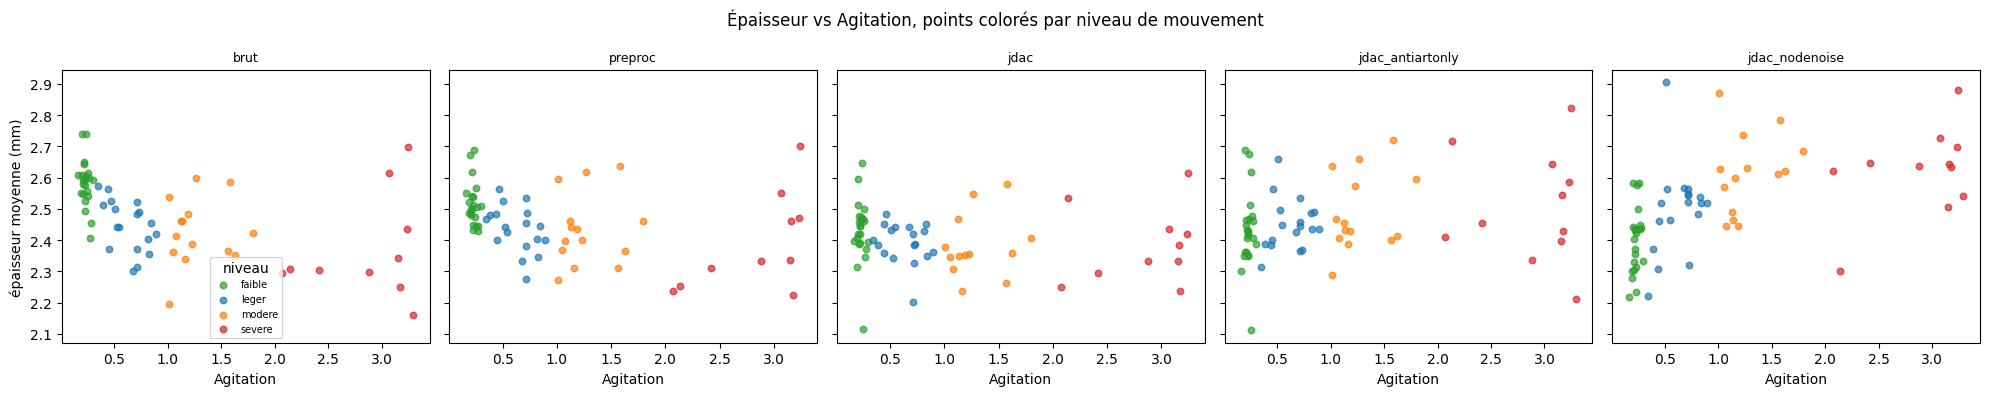

In [7]:
scans = g[["subject", "run", "agitation"]].drop_duplicates().copy()
scans["niveau"] = pd.cut(scans["agitation"], [0, 0.3, 1.0, 2.0, np.inf],
                         labels=["faible", "leger", "modere", "severe"], include_lowest=True)
gb = g.merge(scans[["subject", "run", "niveau"]], on=["subject", "run"])

bornes = gb[["subject", "run", "agitation", "niveau"]].drop_duplicates() \
           .groupby("niveau", observed=True)["agitation"].agg(n="count", min="min", max="max")
show(bornes, "Niveaux de mouvement (bornes Agitation : 0.3, 1.0, 2.0)",
     {"n": "{:.0f}", "min": "{:.2f}", "max": "{:.2f}"})

pivn = (gb.pivot_table(index="niveau", columns="condition", values="thickness",
                       aggfunc="mean", observed=True)
          .reindex(["faible", "leger", "modere", "severe"])[CONDITIONS])
show(pivn, "Épaisseur moyenne (mm) par niveau de mouvement x condition", "{:.3f}")

col_niv = {"faible": "tab:green", "leger": "tab:blue", "modere": "tab:orange", "severe": "tab:red"}
fig, axes = plt.subplots(1, len(CONDITIONS), figsize=(4 * len(CONDITIONS), 4.0), sharey=True)
for ax, c in zip(axes, CONDITIONS):
    sub = gb[gb["condition"] == c]
    for niv, s in sub.groupby("niveau", observed=True):
        ax.scatter(s["agitation"], s["thickness"], s=22, alpha=0.7, color=col_niv[niv], label=niv)
    ax.set_title(c, fontsize=9); ax.set_xlabel("Agitation")
axes[0].set_ylabel("épaisseur moyenne (mm)")
axes[0].legend(title="niveau", fontsize=7)
fig.suptitle("Épaisseur vs Agitation, points colorés par niveau de mouvement")
plt.tight_layout(); plt.show()

## 7. Test par niveau de mouvement : interaction et comparaison par strate

Deux analyses sur les strates de la section 6 : (1) un modèle mixte `épaisseur ~ condition × niveau + (1 | sujet)`, dont l'interaction dit si l'écart entre conditions dépend du niveau de mouvement ; (2) par strate, l'écart de chaque condition au brut avec test apparié de Wilcoxon. Les strates peu peuplées sont peu puissantes, leurs p-values sont indicatives.

In [8]:
# (1) Modèle mixte avec interaction condition x niveau
gi = gb.copy()
gi["condition"] = pd.Categorical(gi["condition"], categories=CONDITIONS)
fit_i = smf.mixedlm("thickness ~ C(condition, Treatment('brut')) * C(niveau, Treatment('faible'))",
                    gi, groups=gi["subject"]).fit(reml=True, method="powell", disp=False)
print("Interaction condition x niveau : l'écart au brut dépend-il du niveau de mouvement ?")
for k in fit_i.params.index:
    if ":" in k:
        cond = k.split("T.")[1].split("]")[0]
        niv = k.split("T.")[-1].rstrip("]")
        print(f"  {cond:16s} x {niv:7s}: {fit_i.params[k]:+.4f}  (p={fit_i.pvalues[k]:.2g})")

Interaction condition x niveau : l'écart au brut dépend-il du niveau de mouvement ?
  preproc          x leger  : +0.0579  (p=0.19)
  jdac             x leger  : +0.0972  (p=0.026)
  jdac_antiartonly x leger  : +0.1560  (p=0.00036)
  jdac_nodenoise   x leger  : +0.2366  (p=7.3e-08)
  preproc          x modere : +0.0758  (p=0.11)
  jdac             x modere : +0.1046  (p=0.028)
  jdac_antiartonly x modere : +0.2168  (p=4.1e-06)
  jdac_nodenoise   x modere : +0.3735  (p=2.8e-15)
  preproc          x severe : +0.0712  (p=0.18)
  jdac             x severe : +0.1503  (p=0.0044)
  jdac_antiartonly x severe : +0.2802  (p=6.4e-08)
  jdac_nodenoise   x severe : +0.4311  (p=1.2e-16)


In [9]:
# (2) Comparaison par strate : écart au brut par niveau, test apparié Wilcoxon
paire = (gb.pivot_table(index=["subject", "run", "niveau"], columns="condition",
                        values="thickness", observed=True)
           .dropna(subset=["brut"]).reset_index())
rows = []
for niv in ["faible", "leger", "modere", "severe"]:
    s = paire[paire["niveau"] == niv]
    rec = {"niveau": niv, "n": len(s)}
    for c in CONDITIONS:
        if c == "brut":
            continue
        ss = s.dropna(subset=[c])
        rec[f"{c} %"] = (100 * (ss[c] - ss["brut"]) / ss["brut"]).mean() if len(ss) else float("nan")
        try:
            rec[f"p({c})"] = stats.wilcoxon(ss[c], ss["brut"]).pvalue if len(ss) >= 3 else float("nan")
        except Exception:
            rec[f"p({c})"] = float("nan")
    rows.append(rec)
strat = pd.DataFrame(rows).set_index("niveau")
fmt = {"n": "{:.0f}"}
for c in CONDITIONS:
    if c != "brut":
        fmt[f"{c} %"] = "{:+.2f}"; fmt[f"p({c})"] = "{:.2g}"
show(strat, "Écart au brut par niveau (%) et test apparié (Wilcoxon)", fmt)

,n,preproc %,p(preproc),jdac %,p(jdac),jdac_antiartonly %,p(jdac_antiartonly),jdac_nodenoise %,p(jdac_nodenoise)
niveau,,,,,,,,,
faible,23,-2.55,4.8e-06,-5.87,2.4e-07,-5.88,7.9e-06,-7.09,4.8e-06
leger,18,-0.40,0.44,-2.18,0.014,+0.22,0.44,+2.21,0.18
modere,14,+0.31,0.54,-2.58,0.0017,+2.66,0.0085,+7.86,0.0012
severe,10,-0.55,0.43,-0.28,0.36,+5.58,0.002,+10.75,0.0039


## 8. Étape 3 (plan Sylvain) — Modèles emboîtés M0 vs M1 (méthode de Charles)

Pour chaque condition, deux modèles mixtes emboîtés (effet aléatoire de sujet, ajustement ML pour le test du rapport de vraisemblance) :
- **M0** : `épaisseur ~ âge + sexe + (1 | sujet)` ;
- **M1** : `épaisseur ~ âge + sexe + Agitation + (1 | sujet)`.

Le score de mouvement améliore-t-il le modèle ? Le test du rapport de vraisemblance (LRT, 1 degré de liberté) et le ΔAIC mesurent l'apport d'Agitation ; le coefficient d'Agitation dans M1 en donne le sens et l'ampleur. Sur le brut, Agitation doit améliorer nettement le modèle (le mouvement prédit l'épaisseur). Après une correction efficace, cet apport doit diminuer (le mouvement ne prédit plus l'épaisseur).

In [10]:
def fit_ml(formula, data):
    return smf.mixedlm(formula, data, groups=data["subject"]).fit(reml=False, method="powell", disp=False)

def aic_mixed(res):
    # Structure aléatoire identique entre M0 et M1 (intercept sujet + variance résiduelle) :
    # ΔAIC = 2*Δk_fixes - 2*Δllf, comparable d'un modèle à l'autre.
    k = len(res.fe_params) + 2
    return -2 * res.llf + 2 * k

rows = []
for c in CONDITIONS:
    sub = g[g["condition"] == c].dropna(subset=["age", "sex_bin", "agitation", "thickness"])
    m0 = fit_ml("thickness ~ age + sex_bin", sub)
    m1 = fit_ml("thickness ~ age + sex_bin + agitation", sub)
    lr = 2 * (m1.llf - m0.llf)
    p_lrt = stats.chi2.sf(lr, 1)
    rows.append(dict(condition=c, n=sub.groupby(["subject", "run"]).ngroups,
                     coef_agitation=m1.params["agitation"], p_agitation=m1.pvalues["agitation"],
                     LRT_chi2=lr, p_LRT=p_lrt, dAIC=aic_mixed(m0) - aic_mixed(m1)))
mtab = pd.DataFrame(rows).set_index("condition").reindex(CONDITIONS)
show(mtab, "M0 (âge+sexe) vs M1 (+Agitation) : apport du score de mouvement, par condition",
     {"n": "{:.0f}", "coef_agitation": "{:+.4f}", "p_agitation": "{:.2g}",
      "LRT_chi2": "{:.2f}", "p_LRT": "{:.2g}", "dAIC": "{:+.2f}"})
print("dAIC > 0 : M1 (avec Agitation) préféré. p_LRT < 0.05 : Agitation améliore le modèle.")

,n,coef_agitation,p_agitation,LRT_chi2,p_LRT,dAIC
condition,,,,,,
brut,65,-0.0662,0.0028,15.93,6.6e-05,+13.93
preproc,64,-0.0308,0.054,4.81,0.028,+2.81
jdac,64,-0.0203,0.094,2.61,0.11,+0.61
jdac_antiartonly,66,+0.0253,0.081,3.05,0.081,+1.05
jdac_nodenoise,65,+0.0923,2.1e-08,24.58,7.1e-07,+22.58


dAIC > 0 : M1 (avec Agitation) préféré. p_LRT < 0.05 : Agitation améliore le modèle.


*Lecture (après exécution).* Comparer l'apport d'Agitation (LRT, ΔAIC, coefficient) entre conditions. Une baisse de cet apport de brut vers une condition de traitement indique que le mouvement prédit moins l'épaisseur après traitement. À croiser avec l'étape 1 : si l'apport baisse mais que l'épaisseur des immobiles baisse aussi, l'effet peut relever du lissage plutôt que d'une correction.

## 9. Étape 3b (plan Sylvain) — Forme non-linéaire, par strate de mouvement

La relation épaisseur-Agitation peut ne pas être linéaire : les strates de la section 6 laissent voir une éventuelle courbure. Pour chaque condition, quatre formes du terme de mouvement sont comparées dans M1 (mêmes covariables âge + sexe, même effet aléatoire de sujet, ajustement ML) :
- **linéaire** : `Agitation` ;
- **quadratique** : `Agitation + Agitation²` ;
- **splines** : splines de base sur Agitation (`bs`, 3 degrés de liberté) ;
- **par strate** : `C(niveau)`, un effet propre à chaque niveau de mouvement.

La comparaison par AIC (et l'inspection des résidus) indique si une forme non-linéaire, ou le découpage par strate, décrit mieux les données que la droite.

In [11]:
def aic_k(res):
    return -2 * res.llf + 2 * (len(res.fe_params) + 2)

formes = {
    "lineaire":     "thickness ~ age + sex_bin + agitation",
    "quadratique":  "thickness ~ age + sex_bin + agitation + I(agitation**2)",
    "splines":      "thickness ~ age + sex_bin + bs(agitation, df=3)",
    "par_strate":   "thickness ~ age + sex_bin + C(niveau)",
}
rows = []
for c in CONDITIONS:
    sub = gb[gb["condition"] == c].dropna(subset=["age", "sex_bin", "agitation", "thickness"])
    rec = {"condition": c}
    aics = {}
    for nom, f in formes.items():
        try:
            res = smf.mixedlm(f, sub, groups=sub["subject"]).fit(reml=False, method="powell", disp=False)
            aics[nom] = aic_k(res)
        except Exception:
            aics[nom] = float("nan")
    base = aics["lineaire"]
    for nom in formes:
        rec[f"dAIC_{nom}"] = aics[nom] - base   # <0 : mieux que le linéaire
    rows.append(rec)
ntab = pd.DataFrame(rows).set_index("condition").reindex(CONDITIONS)
show(ntab, "ΔAIC des formes non-linéaires par rapport au modèle linéaire (par condition)",
     {f"dAIC_{n}": "{:+.2f}" for n in formes})
print("ΔAIC < 0 : forme préférée au linéaire (écart > 2 points = appui notable).")

,dAIC_lineaire,dAIC_quadratique,dAIC_splines,dAIC_par_strate
condition,,,,
brut,+0.00,-13.76,-13.34,-11.61
preproc,+0.00,-10.01,-8.79,-3.27
jdac,+0.00,-2.10,-0.44,+1.62
jdac_antiartonly,+0.00,+1.14,+2.98,+2.99
jdac_nodenoise,+0.00,-6.03,-7.63,-3.36


ΔAIC < 0 : forme préférée au linéaire (écart > 2 points = appui notable).


*Lecture (après exécution).* Une amélioration nette (ΔAIC négatif) de la forme quadratique, des splines ou du découpage par strate signale une relation non linéaire entre mouvement et épaisseur, à décrire à partir des strates de la section 6.

## 10. Synthèse

L'étape 1 (immobiles) isole le lissage ou l'offset propre à chaque condition, indépendamment du mouvement. L'étape 2 mesure l'atténuation de la pente épaisseur-Agitation. L'étape 3 quantifie, par la méthode de Charles, si le mouvement prédit encore l'épaisseur après traitement, et l'étape 3b vérifie si cette relation est linéaire ou non. Les vues par consigne, par niveau et l'interaction condition × niveau apportent le contexte descriptif.

La lecture combine ces éléments : une condition corrige le mouvement si elle réduit l'apport d'Agitation (étape 3) et aplatit la pente (étape 2) sans abaisser l'épaisseur des immobiles (étape 1). Une baisse d'épaisseur sur les immobiles, elle, signe un lissage. Les deux variantes sans débruiteur situent la part de ces effets attribuable au module de débruitage de JDAC.